In [6]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 150)

print("Display settings configured.")

Display settings configured.


In [3]:
BASE_DIR = Path.cwd().parent

DATASET_DIR = BASE_DIR / "dataset"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
FIGURE_DIR = BASE_DIR / "figures"

print(DATASET_DIR)

C:\Users\Lenovo\Resume_AI_Research\dataset


In [8]:
BASE_DIR = Path.cwd().parent

DATASET_DIR = BASE_DIR / "dataset"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = BASE_DIR / "figures"
MODEL_DIR = BASE_DIR / "models"

print(DATASET_DIR)

C:\Users\Lenovo\Resume_AI_Research\dataset


In [9]:
resume_df = pd.read_csv(
    DATASET_DIR / "Resume_Data_For_Ranking.csv"
)

resume_df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,company_urls,start_dates,end_dates,related_skils_in_job,positions,locations,responsibilities,extra_curricular_activity_types,extra_curricular_organization_names,extra_curricular_organization_links,role_positions,languages,proficiency_levels,certification_providers,certification_skills,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with ...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informa...","['The Amity School of Engineering & Technology (ASET), Noida']",['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],[None],['Nov 2019'],['Till Date'],[['Big Data']],['Big Data Analyst'],['N/A'],Technical Support\nTroubleshooting\nCollaboration\nDocumentation\nSystem Monitoring\nSoftware Deployment\nTraining & Mentorship\nIndustry Trends\nField Visits\n\n\n\n\n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a reputed university.,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaboration\nDocumentation\nSystem Monitoring\nSoftware Deployment\nTraining & Mentorship\nIndustry Trends\nField Visits\n\n\n\n\n,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and junior data scientist. Experienced in creating meaningful data dashboards and evaluation models.,"['Data Analysis', 'Data Analytics', 'Business Analysis', 'R', 'SAS', 'PowerBi', 'Tableau', 'Data Visualization', 'Business Analytics', 'Machine Learning']","['Delhi University - Hansraj College', 'Delhi University - Hansraj College']","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],['N/A'],['Sep 2019'],['Till Date'],"[['Data Analysis', 'Business Analysis', 'Machine Learning']]",['Business Analyst'],['N/A'],Machine Learning Leadership\nCross-Functional Collaboration\nStrategy Development\nML/NLP Infrastructure\nPrototype Transformation\nML System Design\nAlgorithm Research\nApplication Development\nD...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in any relevant discipline from a reputed University,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional Collaboration\nStrategy Development\nML/NLP Infrastructure\nPrototype Transformation\nML System Design\nAlgorithm Research\nApplication Development\nD...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', 'Deep Learning', 'Risk Assessment', 'Requirement Gathering', 'Application Support', 'JavaScript', 'Python', 'Docker', 'HTML', 'Hive', 'CSS', 'C', 'C++']","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],['N/A'],['June 2018'],['Till Date'],"[['Unified Payment Interface', 'Risk Prediction', 'Big Data', 'Spark', 'PySpark']]",['Software Developer (Machine Learning Engineer)'],['N/A'],"Trade Marketing Executive\nBrand Visibility, Sales Targets\nField Marketing, Campaigns, Product Distribution\nBrand Head\nExcel, KPIs Tracking",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, Hygiene Products",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, Sales Targets\nField Marketing, Campaigns, Product Distribution\nBrand Head\nExcel,

In [10]:
print("Rows :", resume_df.shape[0])
print("Columns :", resume_df.shape[1])

Rows : 9544
Columns : 35


In [11]:
resume_df.columns.tolist()

['address',
 'career_objective',
 'skills',
 'educational_institution_name',
 'degree_names',
 'passing_years',
 'educational_results',
 'result_types',
 'major_field_of_studies',
 'professional_company_names',
 'company_urls',
 'start_dates',
 'end_dates',
 'related_skils_in_job',
 'positions',
 'locations',
 'responsibilities',
 'extra_curricular_activity_types',
 'extra_curricular_organization_names',
 'extra_curricular_organization_links',
 'role_positions',
 'languages',
 'proficiency_levels',
 'certification_providers',
 'certification_skills',
 'online_links',
 'issue_dates',
 'expiry_dates',
 'job_position_name',
 'educationaL_requirements',
 'experiencere_requirement',
 'age_requirement',
 'responsibilities.1',
 'skills_required',
 'matched_score']

In [12]:
resume_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    str    
 1   career_objective                     4740 non-null   str    
 2   skills                               9488 non-null   str    
 3   educational_institution_name         9460 non-null   str    
 4   degree_names                         9460 non-null   str    
 5   passing_years                        9460 non-null   str    
 6   educational_results                  9460 non-null   str    
 7   result_types                         9460 non-null   str    
 8   major_field_of_studies               9460 non-null   str    
 9   professional_company_names           9460 non-null   str    
 10  company_urls                         9460 non-null   str    
 11  start_dates                          9460

In [13]:
missing = resume_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

proficiency_levels                     8844
languages                              8844
address                                8760
certification_skills                   7536
expiry_dates                           7536
issue_dates                            7536
online_links                           7536
certification_providers                7536
extra_curricular_organization_names    6118
extra_curricular_activity_types        6118
role_positions                         6118
extra_curricular_organization_links    6118
career_objective                       4804
age_requirement                        4087
skills_required                        1701
experiencere_requirement               1364
start_dates                              84
end_dates                                84
educational_results                      84
related_skils_in_job                     84
result_types                             84
company_urls                             84
professional_company_names      

In [14]:
duplicates = resume_df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [15]:
resume_df.describe(include="all")

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,company_urls,start_dates,end_dates,related_skils_in_job,positions,locations,responsibilities,extra_curricular_activity_types,extra_curricular_organization_names,extra_curricular_organization_links,role_positions,languages,proficiency_levels,certification_providers,certification_skills,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
count,784,4740,9488,9460,9460,9460,9460,9460,9460,9460,9460,9460,9460,9460,9460,9460,9544,3426,3426,3426,3426,700,700,2008,2008,2008,2008,2008,9544,9544,8180,5457,9544,7843,9544.000000
unique,28,171,340,328,180,149,78,30,210,199,16,252,246,298,301,86,28,86,89,9,91,18,22,49,32,7,30,11,28,20,17,14,28,23,NaN
top,"Sunnyvale, CA",Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with ...,[],"['Illinois Institute of Technology', 'National Institute of Technology']",['B.Tech'],['2019'],['N/A'],['N/A'],['N/A'],"['Company Name', 'Company Name', 'Company Name']",['N/A'],['Nov 2019'],['Till Date'],[None],['Intern'],['N/A'],Project Design\nData Analysis\nACCORD/Alliance Knowledge\nBNBC Standards\nCost Estimation\nFeasibility Studies\nDocumentation\nCompliance\nSite Monitoring\nPolicy Enforcement\nLegal Compliance\nDa...,['N/A'],['N/A'],[None],['N/A'],"['English', 'Spanish']","['Fluent', 'Fluent', 'Fluent']",['N/A'],[None],[None],['N/A'],[None],Project Coordinator (Civil),Bachelor/Honors,At least 5 years,Age 25 to 40 years,Project Design\nData Analysis\nACCORD/Alliance Knowledge\nBNBC Standards\nCost Estimation\nFeasibility Studies\nDocumentation\nCompliance\nSite Monitoring\nPolicy Enforcement\nLegal Compliance\nDa...,Auto CAD 2D 3D\nCivil 3D\nCivil Construction\nCivil Engineering,NaN
freq,28,28,56,112,1764,1428,3612,3416,616,1204,2436,280,700,280,392,3164,342,196,700,1434,532,168,84,560,832,1196,644,1028,342,2044,1024,1023,342,342,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.660831
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.167040
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.583333
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.683333
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.793333


In [16]:
resume_df["matched_score"].describe()

count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64

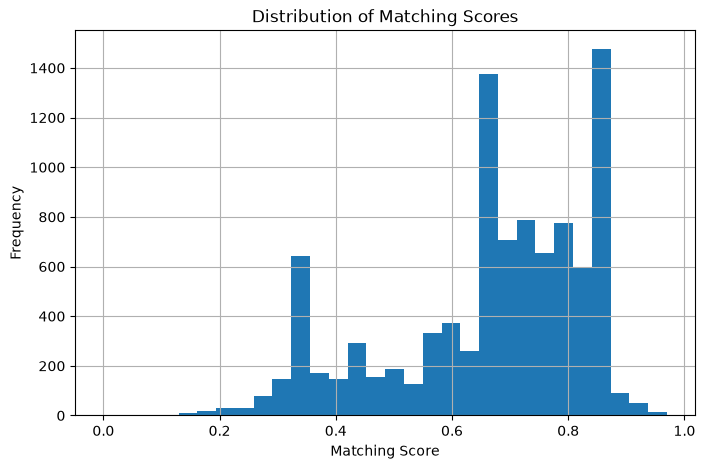

In [17]:
plt.figure(figsize=(8,5))

resume_df["matched_score"].hist(bins=30)

plt.title("Distribution of Matching Scores")
plt.xlabel("Matching Score")
plt.ylabel("Frequency")

plt.show()

In [18]:
plt.savefig(
    FIGURE_DIR/"matching_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [20]:
print(resume_df.columns.tolist())


['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']


In [21]:
resume_df.to_csv(
    DATASET_DIR/"processed/clean_dataset.csv",
    index=False
)